# CS 513 Final Project - NYPD Vehicle Stop Report Data
## Data Visualizations

Name: Samuel Preston and Dean Filippone  
CWID: 10463953 and 20006018  
Assignment: Final Project  
Purpose: Analyze data regarding NYPD Traffic Stops  

##### Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

#models imports
# Naive Bayes
from sklearn.naive_bayes import GaussianNB, CategoricalNB

# ANN (Artificial Neural Network)
from sklearn.neural_network import MLPClassifier

# KNN (K-Nearest Neighbors)
from sklearn.neighbors import KNeighborsClassifier

# CART (Classification and Regression Trees)
from sklearn.tree import DecisionTreeClassifier

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# SVM
from sklearn.svm import SVC

# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

# XGBoost
from xgboost import XGBClassifier

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


##### Reading Data

In [2]:
df = pd.read_csv("nypd_vehicle_stops_Cleaned.csv")

## Data Visualizations

#### Correlation Matrix

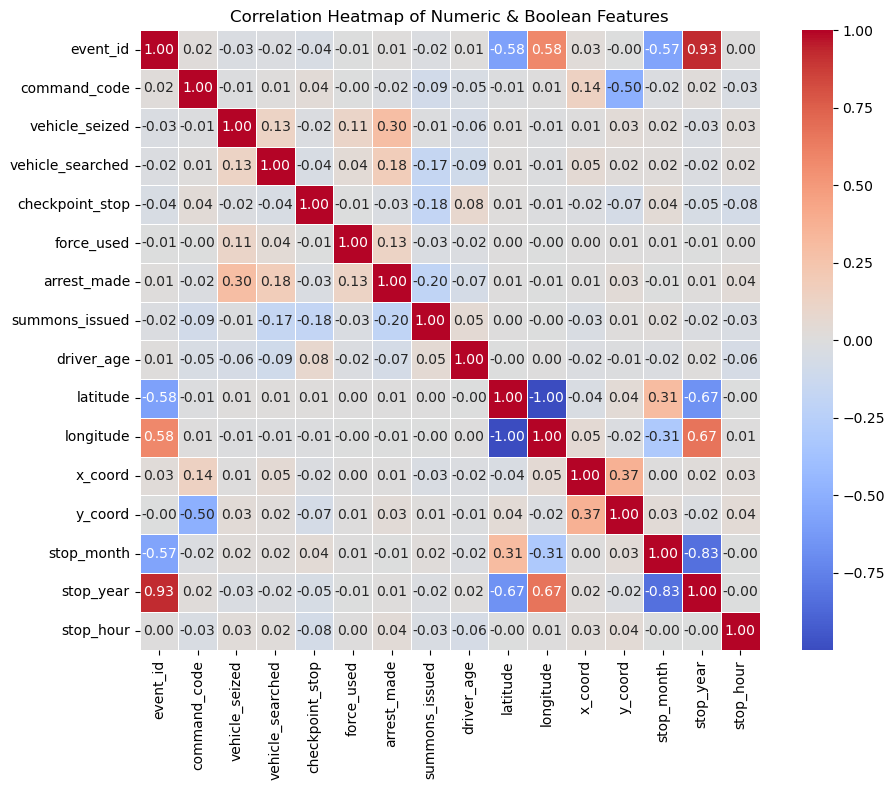

In [3]:
# Correlation Matrix of all attributes

df_cleaned = pd.read_csv('nypd_vehicle_stops_cleaned.csv')

numeric_corr = df_cleaned.select_dtypes(include=['number', 'bool']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric & Boolean Features")
plt.tight_layout()
plt.show()

#### Calculate arrest rate by time of day


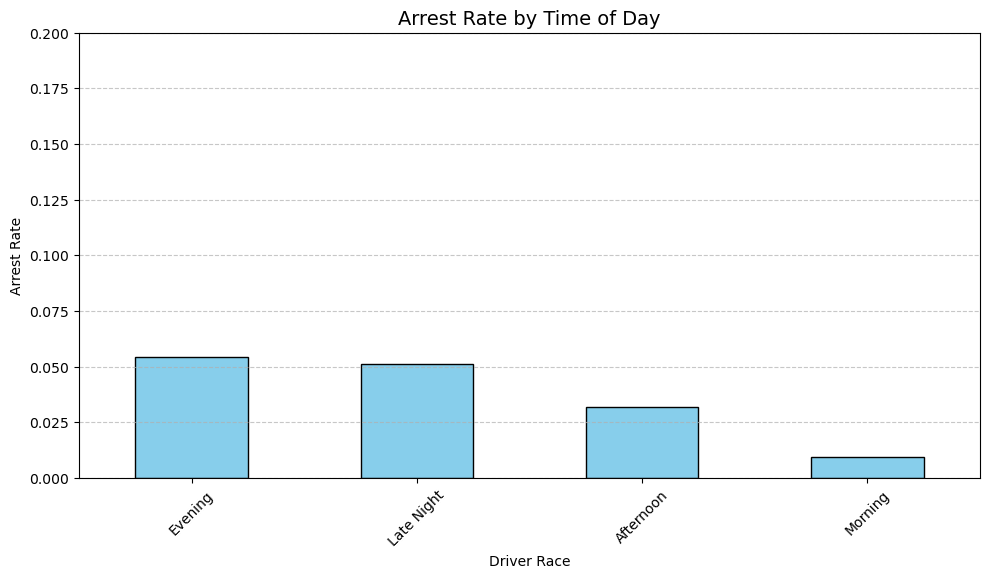

In [4]:
# Calculate arrest rate by time of day
race_arrest_stats = (
    df_cleaned.groupby("stop_time_of_day")["arrest_made"]
    .agg(["count", "sum"])
    .rename(columns={"count": "total_stops", "sum": "arrests"})
)
race_arrest_stats["arrest_rate"] = race_arrest_stats["arrests"] / race_arrest_stats["total_stops"]

# Plot
plt.figure(figsize=(10, 6))
race_arrest_stats["arrest_rate"].sort_values(ascending=False).plot(
    kind="bar", color="skyblue", edgecolor="black"
)
plt.title("Arrest Rate by Time of Day", fontsize=14)
plt.ylabel("Arrest Rate")
plt.xlabel("Driver Race")
plt.ylim(0, .2)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

#### Arrest Rate by Driver Sex

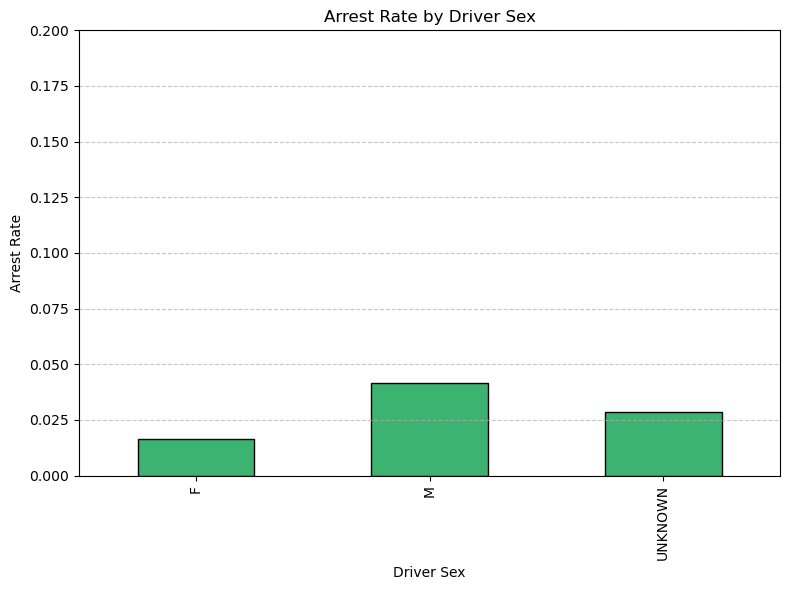

In [5]:
# Calculate arrest rate by driver sex
sex_arrest_stats = (
    df_cleaned.groupby("driver_sex")["arrest_made"]
    .agg(["count", "sum"])
    .rename(columns={"count": "total_stops", "sum": "arrests"})
)
sex_arrest_stats["arrest_rate"] = sex_arrest_stats["arrests"] / sex_arrest_stats["total_stops"]

plt.figure(figsize=(8, 6))
sex_arrest_stats["arrest_rate"].plot(kind="bar", color="mediumseagreen", edgecolor="black")
plt.title("Arrest Rate by Driver Sex")
plt.ylabel("Arrest Rate")
plt.xlabel("Driver Sex")
plt.ylim(0, .2)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


#### Arrest Rate by Driver Race

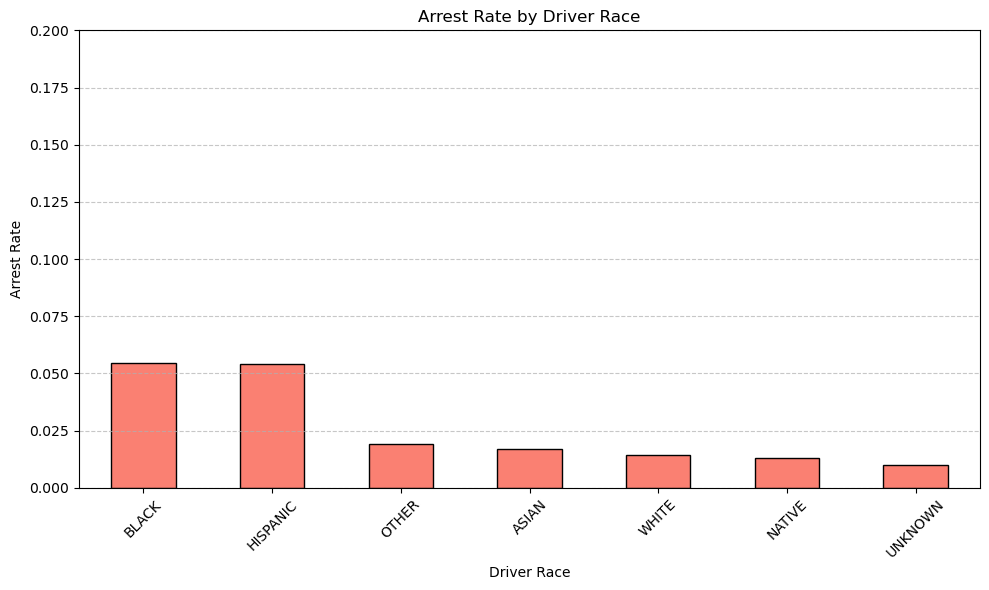

In [6]:
# Calculate arrest rate by driver race
race_arrest_stats = (
    df_cleaned.groupby("driver_race")["arrest_made"]
    .agg(["count", "sum"])
    .rename(columns={"count": "total_stops", "sum": "arrests"})
)
race_arrest_stats["arrest_rate"] = race_arrest_stats["arrests"] / race_arrest_stats["total_stops"]

plt.figure(figsize=(10, 6))
race_arrest_stats["arrest_rate"].sort_values(ascending=False).plot(kind="bar", color="salmon", edgecolor="black")
plt.title("Arrest Rate by Driver Race")
plt.ylabel("Arrest Rate")
plt.xlabel("Driver Race")
plt.ylim(0, .2)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Arrest Rate by Season

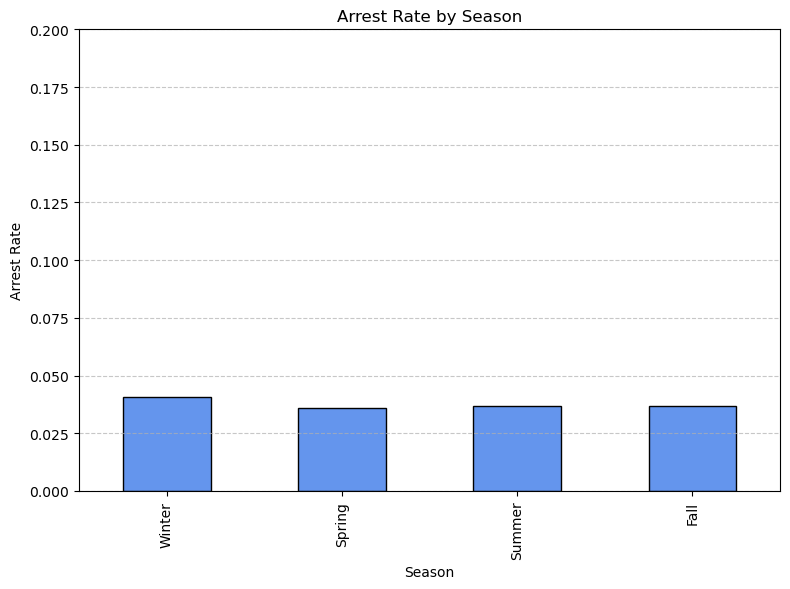

In [7]:
# Calculate arrest rate by season
season_arrest_stats = (
    df_cleaned.groupby("stop_season")["arrest_made"]
    .agg(["count", "sum"])
    .rename(columns={"count": "total_stops", "sum": "arrests"})
)
season_arrest_stats["arrest_rate"] = season_arrest_stats["arrests"] / season_arrest_stats["total_stops"]

plt.figure(figsize=(8, 6))
season_arrest_stats.loc[["Winter", "Spring", "Summer", "Fall"]]["arrest_rate"].plot(
    kind="bar", color="cornflowerblue", edgecolor="black"
)
plt.title("Arrest Rate by Season")
plt.ylabel("Arrest Rate")
plt.xlabel("Season")
plt.ylim(0, .2)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


#### Vehicle Stops per Hour

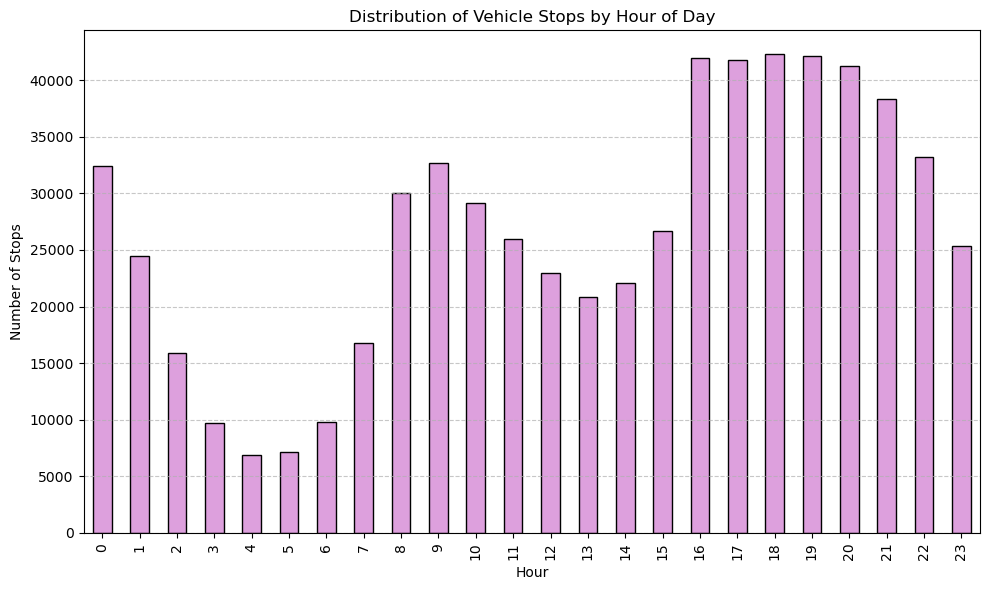

In [8]:
# Calculate vehicle stops per hour
plt.figure(figsize=(10, 6))
df_cleaned["stop_hour"].value_counts().sort_index().plot(kind="bar", color="plum", edgecolor="black")
plt.title("Distribution of Vehicle Stops by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Stops")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


#### Driver Age distribution by Arrest Outcome

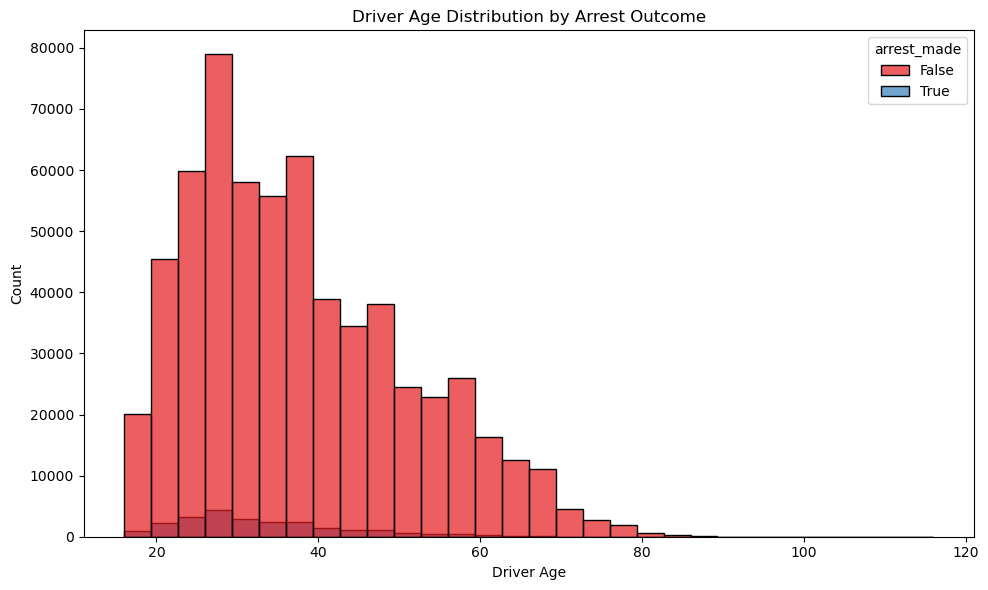

In [9]:
# Driver Age distribution by Arrest outcome
plt.figure(figsize=(10, 6))
sns.histplot(data=df_cleaned, x="driver_age", hue="arrest_made", bins=30, kde=False, palette="Set1", alpha=0.7)
plt.title("Driver Age Distribution by Arrest Outcome")
plt.xlabel("Driver Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


#### Arrest Rate by Day of Week

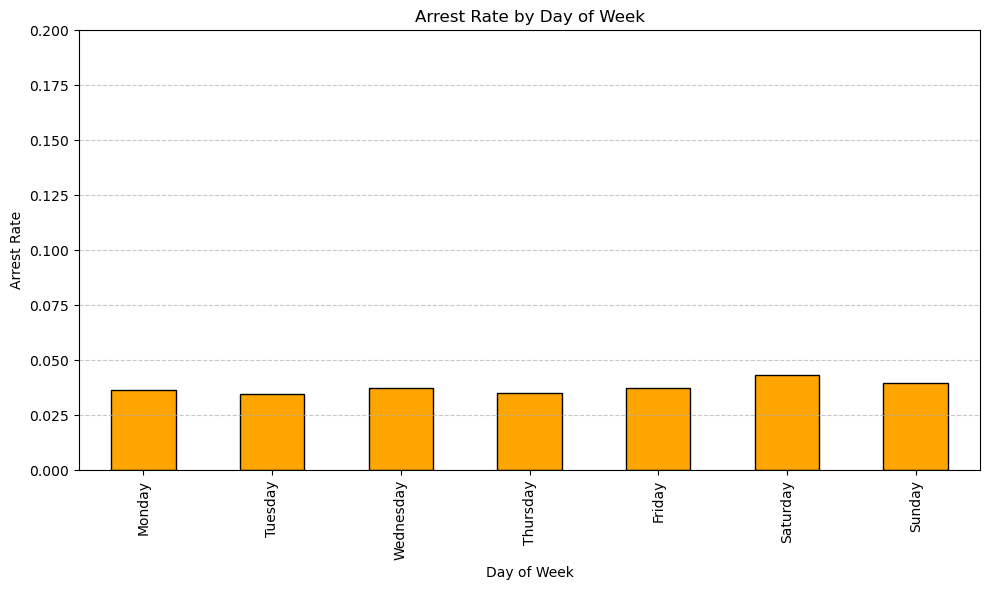

In [10]:
#Arrest rate by day of week
dow_arrest_stats = (
    df_cleaned.groupby("stop_dayofweek")["arrest_made"]
    .agg(["count", "sum"])
    .rename(columns={"count": "total_stops", "sum": "arrests"})
)
dow_arrest_stats["arrest_rate"] = dow_arrest_stats["arrests"] / dow_arrest_stats["total_stops"]

# Ensure correct order
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_arrest_stats = dow_arrest_stats.loc[ordered_days]

plt.figure(figsize=(10, 6))
dow_arrest_stats["arrest_rate"].plot(kind="bar", color="orange", edgecolor="black")
plt.title("Arrest Rate by Day of Week")
plt.ylabel("Arrest Rate")
plt.xlabel("Day of Week")
plt.ylim(0, .2)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


#### Vehicle Types in Stops

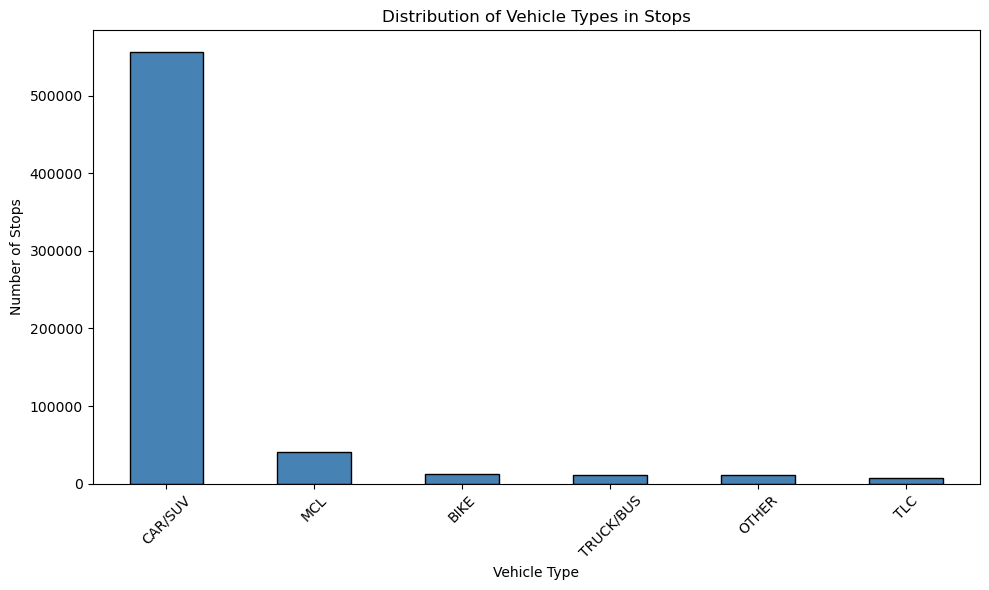

In [11]:
# Distribution of Vechicle Types in Stops
plt.figure(figsize=(10, 6))
df_cleaned["vehicle_type"].value_counts().plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Distribution of Vehicle Types in Stops")
plt.ylabel("Number of Stops")
plt.xlabel("Vehicle Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Arrest Rate by if Force was used

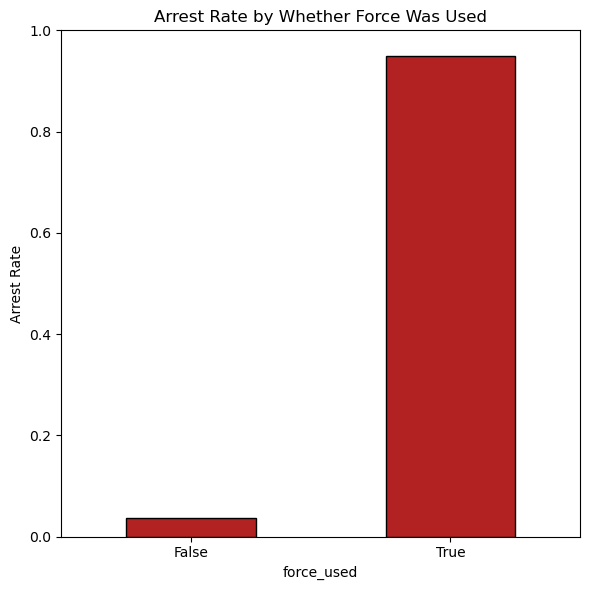

In [12]:
# Arrest Rate by if force was used
force_arrest_stats = (
    df_cleaned.groupby("force_used")["arrest_made"]
    .agg(["count", "sum"])
    .rename(columns={"count": "total_stops", "sum": "arrests"})
)
force_arrest_stats["arrest_rate"] = force_arrest_stats["arrests"] / force_arrest_stats["total_stops"]

plt.figure(figsize=(6, 6))
force_arrest_stats["arrest_rate"].plot(kind="bar", color="firebrick", edgecolor="black")
plt.title("Arrest Rate by Whether Force Was Used")
plt.ylabel("Arrest Rate")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


#### Bounding Box based on Lat & Lon

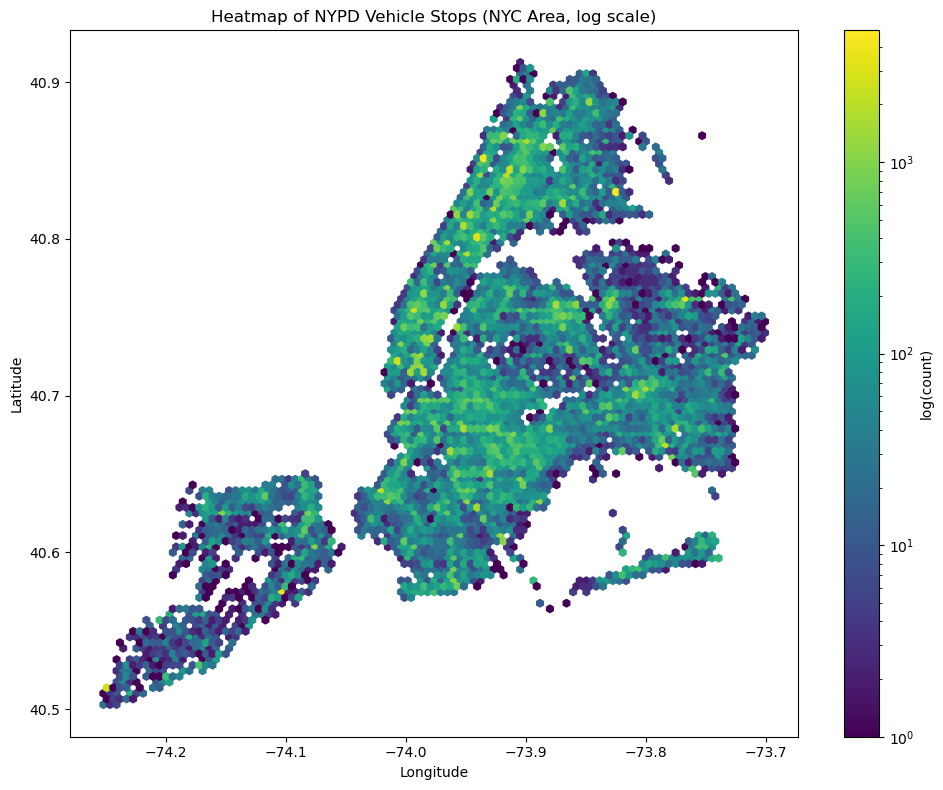

In [13]:
# NYC bounding box: lat ~40.4 to 41.0, lon ~ -74.3 to -73.6
df_geo = df_cleaned[
    (df_cleaned['latitude'] >= 40.4) & (df_cleaned['latitude'] <= 41.0) &
    (df_cleaned['longitude'] >= -74.3) & (df_cleaned['longitude'] <= -73.6)
]

plt.figure(figsize=(10, 8))
plt.hexbin(df_geo['longitude'], df_geo['latitude'], gridsize=100, cmap='viridis', bins='log')
plt.colorbar(label='log(count)')
plt.title("Heatmap of NYPD Vehicle Stops (NYC Area, log scale)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


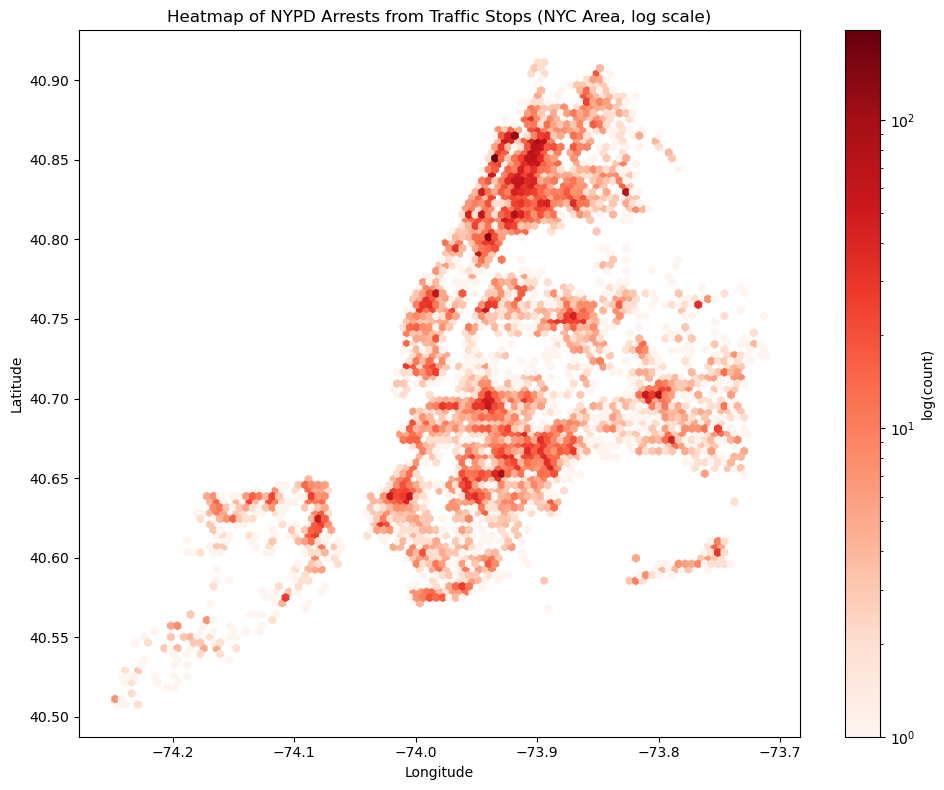

In [31]:
# NYC bounding box: lat ~40.4 to 41.0, lon ~ -74.3 to -73.6
df_arrests = df_cleaned[
    (df_cleaned['arrest_made'] == True) &
    (df_cleaned['latitude'] >= 40.4) & (df_cleaned['latitude'] <= 41.0) &
    (df_cleaned['longitude'] >= -74.3) & (df_cleaned['longitude'] <= -73.6)
]

plt.figure(figsize=(10, 8))
plt.hexbin(df_arrests['longitude'], df_arrests['latitude'], gridsize=100, cmap='Reds', bins='log')
plt.colorbar(label='log(count)')
plt.title("Heatmap of NYPD Arrests from Traffic Stops (NYC Area, log scale)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


#### Arrest Rate by Age Group

/tmp/ipykernel_2938/2370996821.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cleaned.groupby("age_group")["arrest_made"]


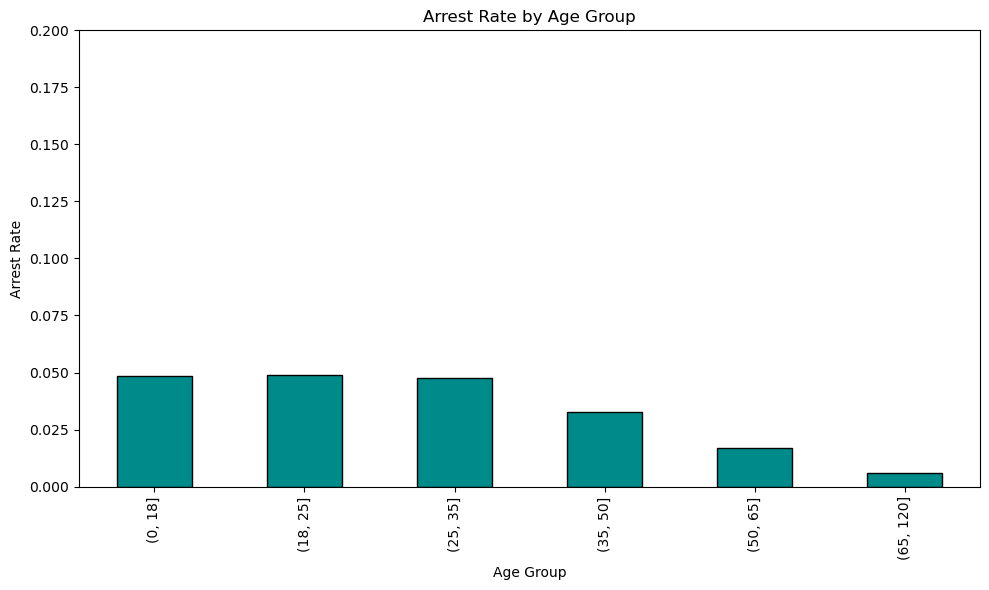

In [14]:
# Arrest Rate by age group
df_cleaned["age_group"] = pd.cut(df_cleaned["driver_age"], bins=[0, 18, 25, 35, 50, 65, 120])

age_arrest_stats = (
    df_cleaned.groupby("age_group")["arrest_made"]
    .agg(["count", "sum"])
    .rename(columns={"count": "total", "sum": "arrests"})
)
age_arrest_stats["arrest_rate"] = age_arrest_stats["arrests"] / age_arrest_stats["total"]

plt.figure(figsize=(10, 6))
age_arrest_stats["arrest_rate"].plot(kind="bar", color="darkcyan", edgecolor="black")
plt.title("Arrest Rate by Age Group")
plt.ylabel("Arrest Rate")
plt.xlabel("Age Group")
plt.ylim(0, .2)
plt.tight_layout()
plt.show()


#### Arrest Rate by Driver Race & Sex

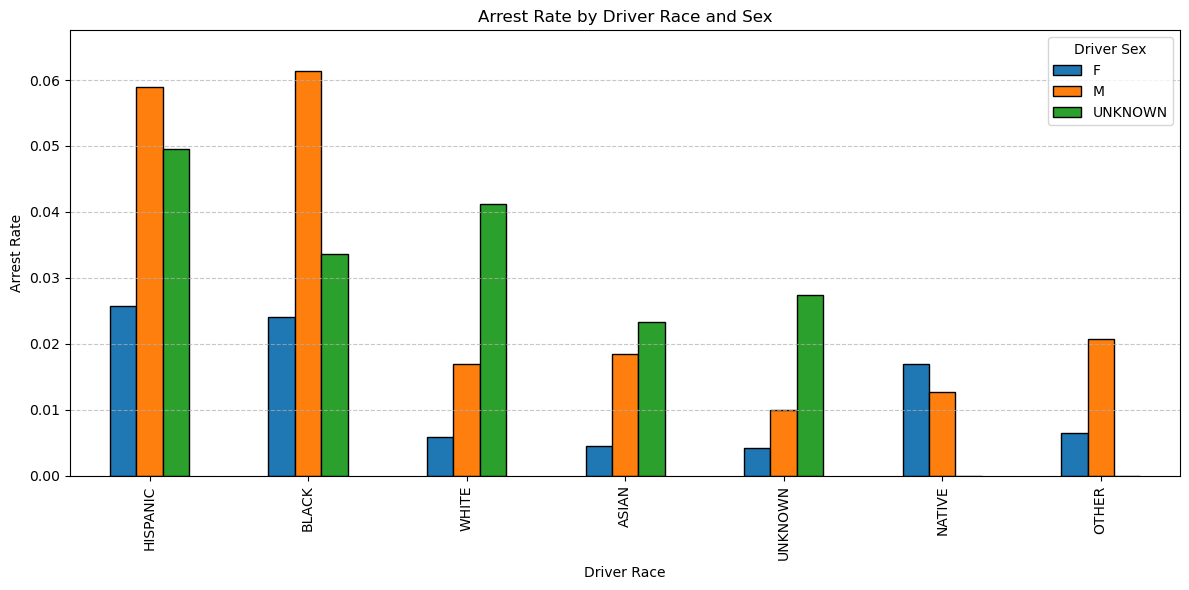

In [15]:
# Arrest rate by driver race & Sex

# Group by both race and sex
group_stats = (
    df_cleaned.groupby(['driver_race', 'driver_sex'])['arrest_made']
    .agg(['count', 'sum'])
    .rename(columns={'count': 'total_stops', 'sum': 'arrests'})
)

# Compute arrest rate
group_stats['arrest_rate'] = group_stats['arrests'] / group_stats['total_stops']
group_stats = group_stats.reset_index()

# Pivot to prepare for grouped bar plot
pivot_table = group_stats.pivot(index='driver_race', columns='driver_sex', values='arrest_rate').fillna(0)

# Sort by average arrest rate across sexes (optional for readability)
pivot_table['mean'] = pivot_table.mean(axis=1)
pivot_table = pivot_table.sort_values('mean', ascending=False).drop(columns='mean')

# Plot
pivot_table.plot(kind='bar', figsize=(12, 6), edgecolor='black')
plt.title("Arrest Rate by Driver Race and Sex")
plt.ylabel("Arrest Rate")
plt.xlabel("Driver Race")
plt.ylim(0, group_stats['arrest_rate'].max() * 1.1)
plt.legend(title="Driver Sex")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#### Pie Chart on Total Stops by Time of Day

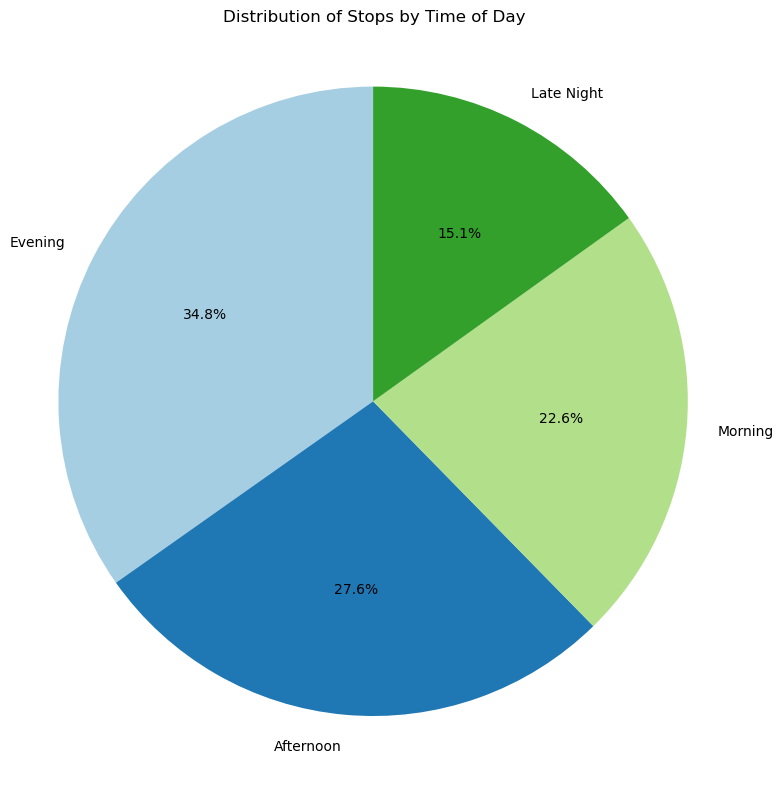

In [16]:
# Pie chart for total stops by time of day
time_counts = df_cleaned["stop_time_of_day"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    time_counts,
    labels=time_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Paired.colors
)
plt.title("Distribution of Stops by Time of Day")
plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle.
plt.tight_layout()
plt.show()


#### Boxplot on Arrests by Driver Age

/tmp/ipykernel_2938/1654995884.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x="arrest_status", y="driver_age", palette="Set2")


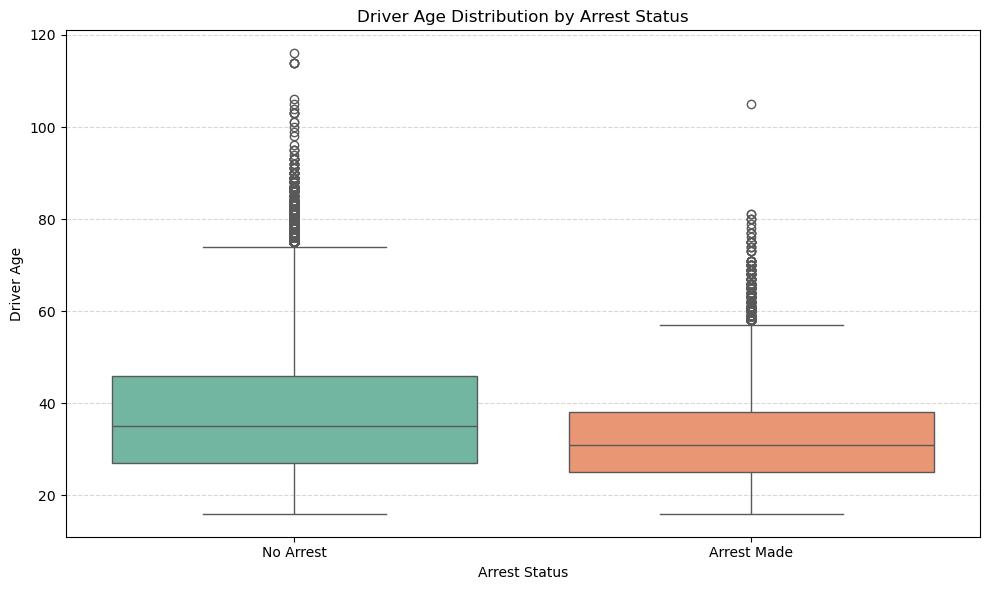

In [17]:
# Clean display labels for boxplot
df_cleaned["arrest_status"] = df_cleaned["arrest_made"].map({True: "Arrest Made", False: "No Arrest"})

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_cleaned, x="arrest_status", y="driver_age", palette="Set2")
plt.title("Driver Age Distribution by Arrest Status")
plt.xlabel("Arrest Status")
plt.ylabel("Driver Age")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
